In [1]:
from trainer import Trainer
from optimizer import SGD
from module import Sequential
from loss import CrossEntropyLoss, LogLoss, MSELoss
from data import Dataset, DataLoader, choose_dataset
from sklearn.model_selection import train_test_split

import os
import nn
import tensyx as ts
import matplotlib.pyplot as plt

# **Binary Classification**

In [16]:
epochs = 10
n_samples = 1250
n_features = 100
dataset_type = "blobs"
classes = 2
learning_rate = 1
milestones = []
batch_size = 4
val_size = 0.2
metrics = ["accuracy", "precision", "recall", "f1_score"]

hi_features = 2**2

#model = Sequential((nn.Linear(n_features, hi_features), nn.ReLU(), nn.Linear(hi_features, 1), nn.Sigmoid()))
model = Sequential((nn.Linear(n_features, 1)), nn.Sigmoid())
print(f"Model's parameters: {model.count_parameters()}")
optimizer = SGD(model, learning_rate, milestones)
loss = LogLoss()

X, Y = choose_dataset(dataset_type = dataset_type, random_state=0, last_module=model[-1], n_samples = n_samples, n_features = n_features, classes = classes, biais=0)
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=val_size, random_state=42)

X_train = ts.Tensor(X_train, requires_grad=False)
X_validation = ts.Tensor(X_validation, requires_grad=False)

Y_train = ts.Tensor(Y_train, requires_grad=False)
Y_validation = ts.Tensor(Y_validation, requires_grad=False)
val_size = 0.2
train_dataset = Dataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=42, shuffle_iteration=True)

validation_dataset = Dataset(X_validation, Y_validation)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=42)

trainer = Trainer(epochs, model, optimizer, loss, dataset_type, train_loader, num_classes=classes, metrics=metrics)
trainer()

Model's parameters: 101
Epoch: 0/10


100%|██████████| 250/250 [00:00<00:00, 1306.91it/s, Train_accuracy=0.75, Train_precision=0.833, Train_recall=0.75, Train_f1_score=0.789, Train_loss=0.692]


Train accuracy: 0.468 | Train precision: 0.48 | Train recall: 0.463 | Train f1_score: 0.45 | Train loss: 0.705 | 



Epoch: 1/10


100%|██████████| 250/250 [00:00<00:00, 943.13it/s, Train_accuracy=1, Train_precision=1, Train_recall=1, Train_f1_score=1, Train_loss=0.000779] 


Train accuracy: 0.984 | Train precision: 0.979 | Train recall: 0.985 | Train f1_score: 0.98 | Train loss: 0.076 | 



Epoch: 2/10


...

Train accuracy: 1.0 | Train precision: 1.0 | Train recall: 1.0 | Train f1_score: 1.0 | Train loss: 0.001 | 



Epoch: 9/10


100%|██████████| 250/250 [00:00<00:00, 1132.47it/s, Train_accuracy=1, Train_precision=1, Train_recall=1, Train_f1_score=1, Train_loss=3.4e-5]  


Train accuracy: 1.0 | Train precision: 1.0 | Train recall: 1.0 | Train f1_score: 1.0 | Train loss: 0.0 | 



Epoch: 10/10


100%|██████████| 250/250 [00:00<00:00, 1109.15it/s, Train_accuracy=1, Train_precision=1, Train_recall=1, Train_f1_score=1, Train_loss=0.000302]


Train accuracy: 1.0 | Train precision: 1.0 | Train recall: 1.0 | Train f1_score: 1.0 | Train loss: 0.0 | 





# **Classification Multi-Class**

In [ ]:
epochs = 10
n_samples = 1250
n_features = 2
dataset_type = "blobs"
classes = 10
learning_rate = 1
milestones = []
batch_size = 4
val_size = 0.2
metrics = ["accuracy", "precision", "recall", "f1_score"]

hi_features = 2**1

model = Sequential((nn.Linear(n_features, classes), nn.Softmax()))
print(f"Model's parameters: {model.count_parameters()}")
optimizer = SGD(model, learning_rate, milestones)
loss = CrossEntropyLoss()

X, Y = choose_dataset(dataset_type = dataset_type, random_state=0, last_module=model[-1], n_samples = n_samples, n_features = n_features, classes = classes, biais=0)
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=val_size, random_state=42)

X_train = ts.Tensor(X_train, requires_grad=False)
X_validation = ts.Tensor(X_validation, requires_grad=False)

Y_train = ts.Tensor(Y_train, requires_grad=False)
Y_validation = ts.Tensor(Y_validation, requires_grad=False)
val_size = 0.2
train_dataset = Dataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=42, shuffle_iteration=True)

validation_dataset = Dataset(X_validation, Y_validation)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=42)

trainer = Trainer(epochs, model, optimizer, loss, dataset_type, train_loader, num_classes=classes, metrics=metrics)
trainer()

# **Non-linear Regression**

Model's parameters: 2
Epoch: 0/15


100%|██████████| 4500/4500 [00:01<00:00, 2304.84it/s, Train_loss=8.81]  


Train loss: 3.404 | 



Epoch: 1/15


100%|██████████| 4500/4500 [00:02<00:00, 1869.59it/s, Train_loss=1.31]    


Train loss: 1.429 | 



Epoch: 2/15


...

Train loss: 1.217 | 



Epoch: 14/15


100%|██████████| 4500/4500 [00:02<00:00, 1977.63it/s, Train_loss=0.91]    


Train loss: 1.302 | 



Epoch: 15/15


100%|██████████| 4500/4500 [00:02<00:00, 1891.56it/s, Train_loss=0.0549]  


Train loss: 1.419 | 





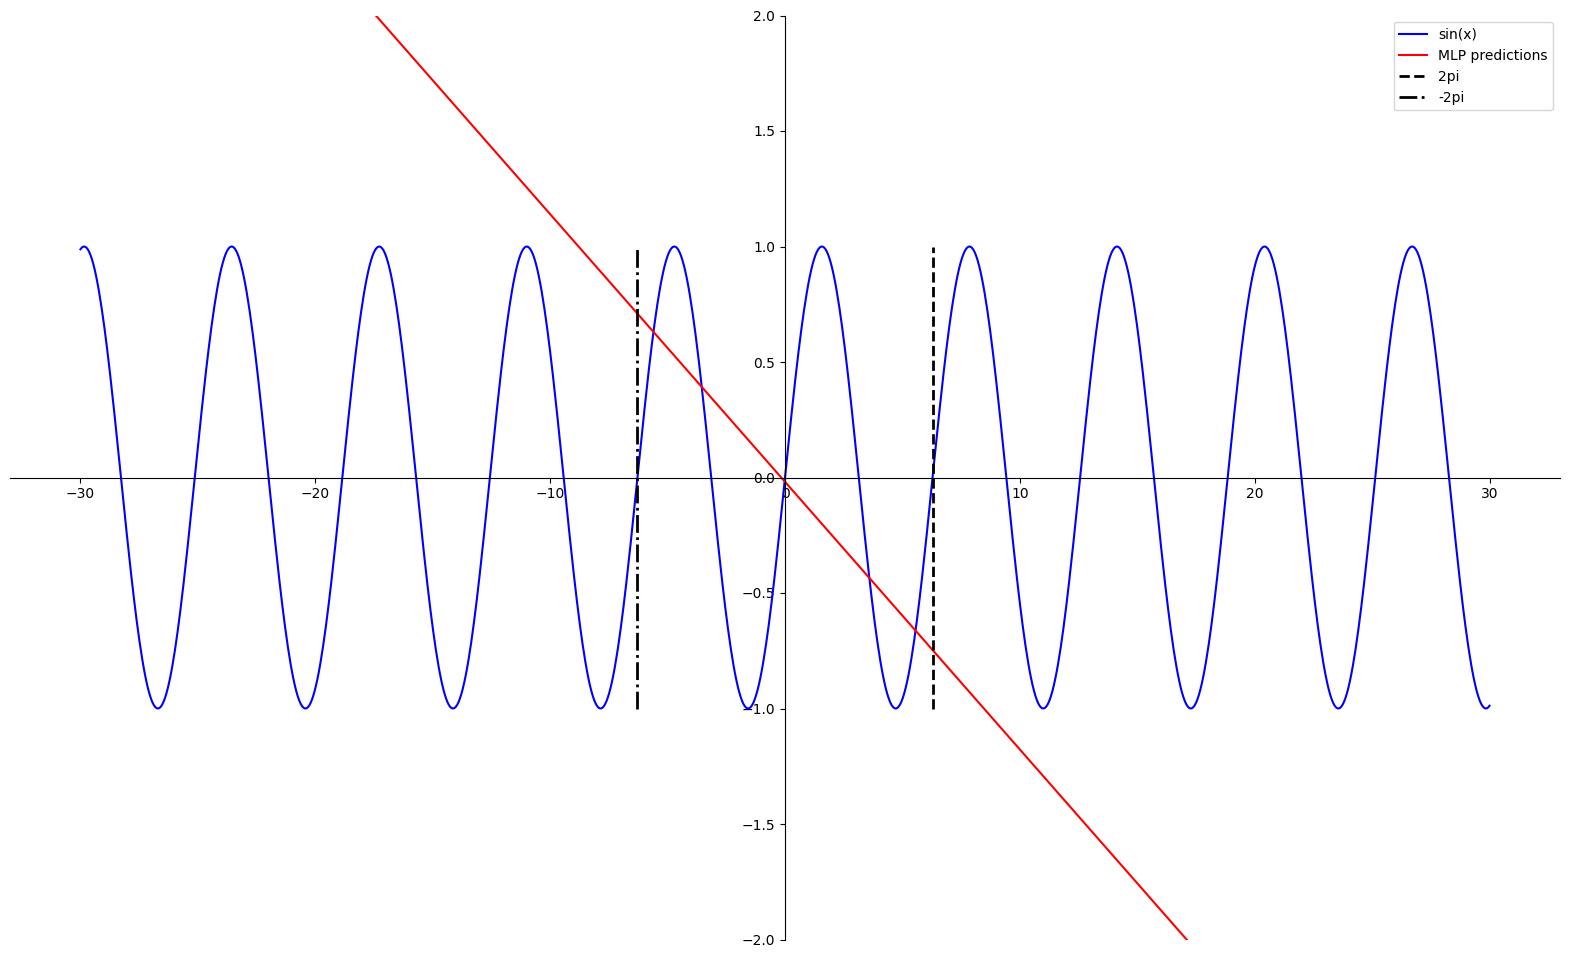

In [4]:
epochs = 15
n_samples = 10000
n_features = 1
dataset_type = "non_linear_regression"
classes = 1
learning_rate = 5e-2
milestones = []
batch_size = 2
val_size = 0.1
metrics = []

hi_features = 2**3

model = Sequential(nn.Linear(n_features, 1))
print(f"Model's parameters: {model.count_parameters()}")
optimizer = SGD(model, learning_rate, milestones)
loss = MSELoss()

X, Y = choose_dataset(dataset_type = dataset_type, random_state=0, last_module=model[-1], n_samples = n_samples, n_features = n_features, classes = classes, biais=0)
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=val_size, random_state=42)

X_train = ts.Tensor(X_train, requires_grad=False)
X_validation = ts.Tensor(X_validation, requires_grad=False)

Y_train = ts.Tensor(Y_train, requires_grad=False)
Y_validation = ts.Tensor(Y_validation, requires_grad=False)

train_dataset = Dataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=42, shuffle_iteration=True)

validation_dataset = Dataset(X_validation, Y_validation)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=42)

trainer = Trainer(epochs, model, optimizer, loss, dataset_type, train_loader, num_classes=classes, metrics=metrics)
trainer()

X = ts.Tensor(ts.np.expand_dims(ts.np.linspace(-30, 30, 1000), -1))

_, ax = plt.subplots(1, 1, figsize=(20, 12))
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.plot(X.tensor, ts.np.sin(X.tensor), c="blue", linewidth=1.5, label="sin(x)")
ax.plot(X.tensor, model(X).tensor, c="red", linewidth=1.5, label="MLP predictions")
ax.plot([2 * ts.np.pi] * 100, ts.np.linspace(-1, 1, 100), c="black", linewidth=2, linestyle="dashed", label="2pi")
ax.plot([- 2 * ts.np.pi] * 100, ts.np.linspace(-1, 1, 100), c="black", linewidth=2, linestyle="dashdot", label="-2pi")
ax.set_ylim(-2, 2)
ax.legend()
plt.savefig(os.path.join(os.path.dirname(""), "documentations/plots", f"MLP_sin_predictions_{n_samples}"), pad_inches=0.)